In [16]:
import pandas as pd
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from transformers import pipeline

In [9]:
data = pd.read_csv("book_reviews_sample.csv")
data

,index,reviewText,rating
0,11494,Clean and funny. A bit busy with all the diffe...,3
1,984,Alex a sexy hot cop and the PhD candidate. Wha...,4
2,1463,Good thing that this is a free story. I read i...,1
3,10342,"Action, action, action! Equipment keeps gettin...",4
4,5256,this was hands down the worse book i have ever...,1
...,...,...,...
95,1794,Love this author. I have read most of her book...,5
96,6716,This book was not bad! I like the storyline ! ...,2
97,7372,This is part of a series I read and I loved th...,5
98,5676,Finally a Texas newspaper in Kindle format.Way...,4


In [10]:
data["text_blob"] = data.apply(lambda col : TextBlob(col["reviewText"]).polarity, axis=1)

In [11]:
analyzer = SentimentIntensityAnalyzer()

In [13]:
data["vadar"] = data.apply(lambda col : analyzer.polarity_scores(col["reviewText"])["compound"], axis=1)

In [17]:
pipe = pipeline("text-classification")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


In [20]:
data["pipeline"] =data.apply(lambda col : pipe(col["reviewText"])[0]["score"], axis=1)

In [27]:
data["rate"] = pd.cut(data["pipeline"], bins = [-1,-0.1,0.1,1], labels =  ['negative', 'neutral', 'positive'])

<Axes: ylabel='rate'>

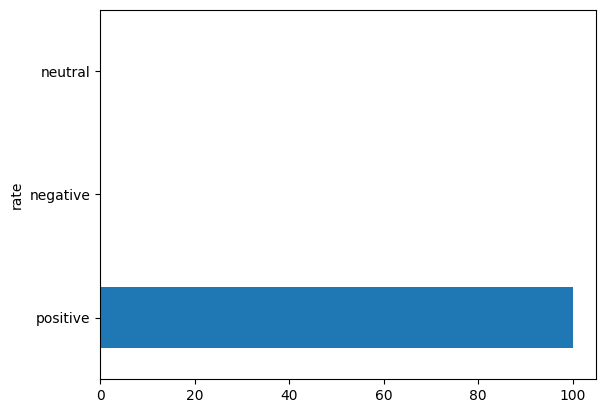

In [34]:
data["rate"].value_counts().plot(kind="barh")